# Sunset Data Analysis

This notebook analyzes the UCSD Sunset community dataset (2023–present),
which contains detailed grade distributions per course section.

Author: Minghong Sun

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import re
from pathlib import Path

root_dir = Path().resolve().parents[0]
df_raw = pd.read_csv(root_dir / 'data' / 'sunset_data.csv')

print(f'Sunset rows: {len(df_raw):,}')
print('Columns:', df_raw.columns.tolist())
df_raw.head(3)

Sunset rows: 10,429
Columns: ['Submission time', 'User ID', 'Term', 'Course', 'Professor', 'Grade distribution', 'Recommend professor?']


,Submission time,User ID,Term,Course,Professor,Grade distribution,Recommend professor?
0,2023-12-23T05:50:18.840Z,259100ef37d22fcae62b973b4933094bcee3496ac77926...,Fall Qtr 2023,CSE 167,"Li, Tzumao","A+:102, A:22, A-:11, B+:5, B:7, B-:6, C+:2, C:...",NaN
1,2023-12-23T05:50:18.840Z,259100ef37d22fcae62b973b4933094bcee3496ac77926...,Spring Qtr 2023,CSE 101,"Jones, Miles E","A+:44, A:63, A-:45, B+:27, B:19, B-:11, C+:8, ...",NaN
2,2023-12-23T05:50:18.840Z,259100ef37d22fcae62b973b4933094bcee3496ac77926...,Spring Qtr 2023,CSE 110,"Powell, Thomas Allan","A+:0, A:17, A-:7, B+:9, B:6, B-:4, C+:1, C:0, ...",NaN


## 2. Parse Grade Distribution

In [2]:
# Grade points mapping
GRADE_POINTS = {
    'A+': 4.0, 'A': 4.0, 'A-': 3.7,
    'B+': 3.3, 'B': 3.0, 'B-': 2.7,
    'C+': 2.3, 'C': 2.0, 'C-': 1.7,
    'D+': 1.3, 'D': 1.0, 'D-': 0.7,
    'F':  0.0
}

def parse_grade_dist(s):
    """Parse 'A+:102, A:22, ...' into a dict of {grade: count}."""
    if pd.isna(s):
        return {}
    result = {}
    for part in str(s).split(','):
        part = part.strip()
        m = re.match(r'([A-Z][+-]?):(\d+)', part)
        if m:
            result[m.group(1)] = int(m.group(2))
    return result

def calc_gpa(dist):
    """Calculate GPA from grade distribution dict."""
    total_pts = 0
    total_cnt = 0
    for grade, count in dist.items():
        if grade in GRADE_POINTS:
            total_pts += GRADE_POINTS[grade] * count
            total_cnt += count
    return total_pts / total_cnt if total_cnt > 0 else None

df = df_raw.copy()
df.columns = df.columns.str.strip()

df['grade_dist'] = df['Grade distribution'].apply(parse_grade_dist)
df['GPA']        = df['grade_dist'].apply(calc_gpa)

# Expand each letter grade count into its own column
grade_cols = pd.DataFrame(df['grade_dist'].tolist(), index=df.index).fillna(0)
for col in GRADE_POINTS:
    if col not in grade_cols.columns:
        grade_cols[col] = 0
grade_cols = grade_cols[[g for g in GRADE_POINTS if g in grade_cols.columns]]
df = pd.concat([df, grade_cols], axis=1)

# Extract department & term
df['Department'] = df['Course'].str.extract(r'^([A-Z]+)')
df['Term_clean'] = df['Term'].str.replace(' Qtr', '').str.strip()

df_clean = df.dropna(subset=['GPA', 'Department'])
print(f'Clean rows: {len(df_clean):,}')
print(f'Terms: {sorted(df_clean["Term_clean"].unique())}')
df_clean[['Course', 'Professor', 'Term_clean', 'GPA']].head(5)

Clean rows: 9,586
Terms: ['Fall 2019', 'Fall 2020', 'Fall 2021', 'Fall 2022', 'Fall 2023', 'Fall 2024', 'Fall 2025', 'SpecSumSes 2021', 'SpecSumSes 2022', 'SpecSumSes 2023', 'SpecSumSes 2024', 'SpecSumSes 2025', 'Spring 2020', 'Spring 2021', 'Spring 2022', 'Spring 2023', 'Spring 2024', 'Spring 2025', 'Sum Ses I 2020', 'Sum Ses I 2021', 'Sum Ses I 2022', 'Sum Ses I 2023', 'Sum Ses I 2024', 'Sum Ses I 2025', 'Sum Ses II 2020', 'Sum Ses II 2021', 'Sum Ses II 2022', 'Sum Ses II 2023', 'Sum Ses II 2024', 'Sum Ses II 2025', 'Winter 2020', 'Winter 2021', 'Winter 2022', 'Winter 2023', 'Winter 2024', 'Winter 2025']


,Course,Professor,Term_clean,GPA
0,CSE 167,"Li, Tzumao",Fall 2023,3.709756
1,CSE 101,"Jones, Miles E",Spring 2023,3.475652
2,CSE 110,"Powell, Thomas Allan",Spring 2023,3.475556
3,PHYS 2C,"Yang, Liang",Spring 2023,2.942857
4,CAT 125,"Bigham, David Joseph",Winter 2023,3.900000


## 3. Overall Grade Distribution (Sunset)

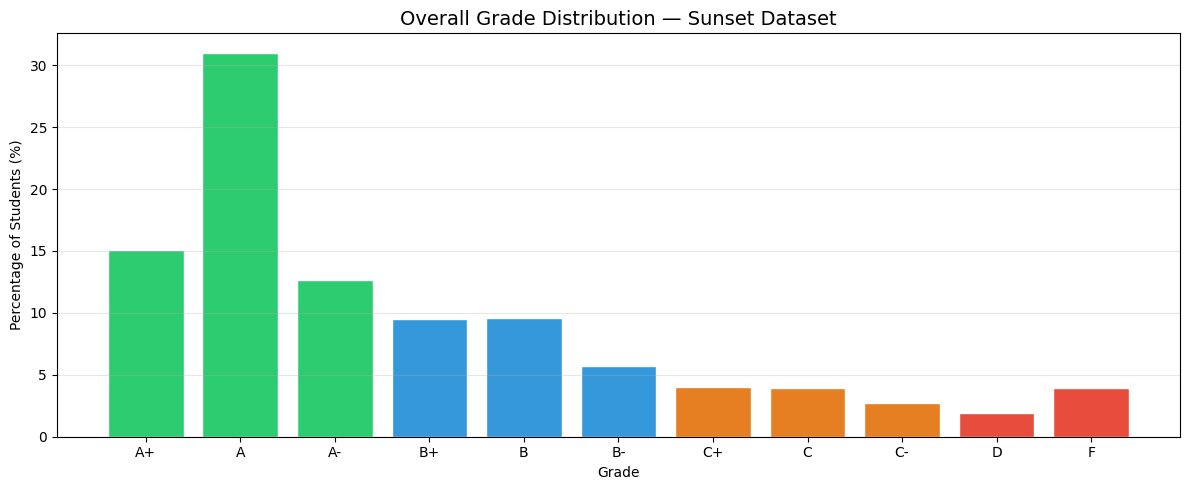

Overall GPA (Sunset): 3.292


In [3]:
grade_order = ['A+', 'A', 'A-', 'B+', 'B', 'B-', 'C+', 'C', 'C-', 'D', 'F']
grade_order = [g for g in grade_order if g in df_clean.columns]

grade_totals = df_clean[grade_order].sum()
grade_pct    = grade_totals / grade_totals.sum() * 100

fig, ax = plt.subplots(figsize=(12, 5))
colors = (['#2ecc71'] * 3 + ['#3498db'] * 3 +
          ['#e67e22'] * 3 + ['#e74c3c'] * 2)
ax.bar(grade_order, grade_pct, color=colors[:len(grade_order)], edgecolor='white')
ax.set_title('Overall Grade Distribution — Sunset Dataset', fontsize=14)
ax.set_xlabel('Grade')
ax.set_ylabel('Percentage of Students (%)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/sunset_overall_dist.png', dpi=150)
plt.show()

print(f'Overall GPA (Sunset): {df_clean["GPA"].mean():.3f}')

## 4. GPA by Department (Top 15)

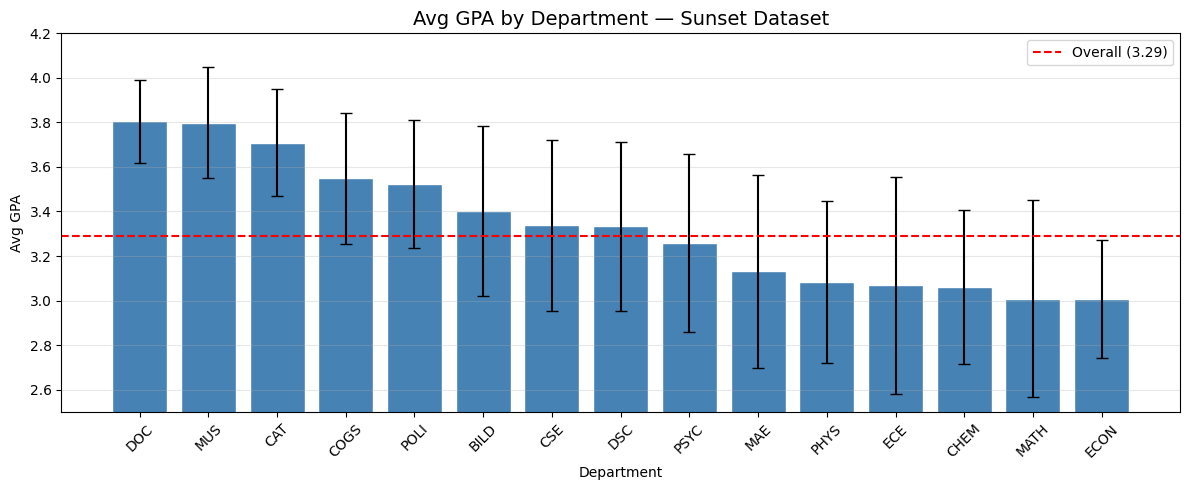

In [4]:
top15 = df_clean['Department'].value_counts().head(15).index

dept_gpa = (
    df_clean[df_clean['Department'].isin(top15)]
    .groupby('Department')['GPA']
    .agg(['mean', 'std', 'count'])
    .sort_values('mean', ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(dept_gpa.index, dept_gpa['mean'],
       yerr=dept_gpa['std'], capsize=4,
       color='steelblue', edgecolor='white')
ax.axhline(df_clean['GPA'].mean(), color='red', linestyle='--',
           linewidth=1.5, label=f'Overall ({df_clean["GPA"].mean():.2f})')
ax.set_title('Avg GPA by Department — Sunset Dataset', fontsize=14)
ax.set_xlabel('Department')
ax.set_ylabel('Avg GPA')
ax.set_ylim(2.5, 4.2)
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/sunset_dept_gpa.png', dpi=150)
plt.show()

## 5. Grade Distribution by Term

                     mean  count
Term_clean                      
Fall 2019        3.182754     30
Fall 2020        3.393378    133
Fall 2021        3.271611    361
Fall 2022        3.336327    753
Fall 2023        3.275451   1238
Fall 2024        3.291754    770
Fall 2025        3.293925    429
SpecSumSes 2021  3.529569      9
SpecSumSes 2022  3.440482      6
SpecSumSes 2023  3.414056      6
SpecSumSes 2024  3.464633      3
SpecSumSes 2025  3.295023      5
Spring 2020      3.601163     35
Spring 2021      3.416479    135
Spring 2022      3.204554    371
Spring 2023      3.274240    771
Spring 2024      3.272493    555
Spring 2025      3.293380    537
Sum Ses I 2020   3.311578     17
Sum Ses I 2021   3.311634     20
Sum Ses I 2022   3.265635     48
Sum Ses I 2023   3.304200     79
Sum Ses I 2024   3.279632     49
Sum Ses I 2025   3.350908     53
Sum Ses II 2020  3.502912     13
Sum Ses II 2021  3.309842     18
Sum Ses II 2022  3.459502     71
Sum Ses II 2023  3.297563    116
Sum Ses II

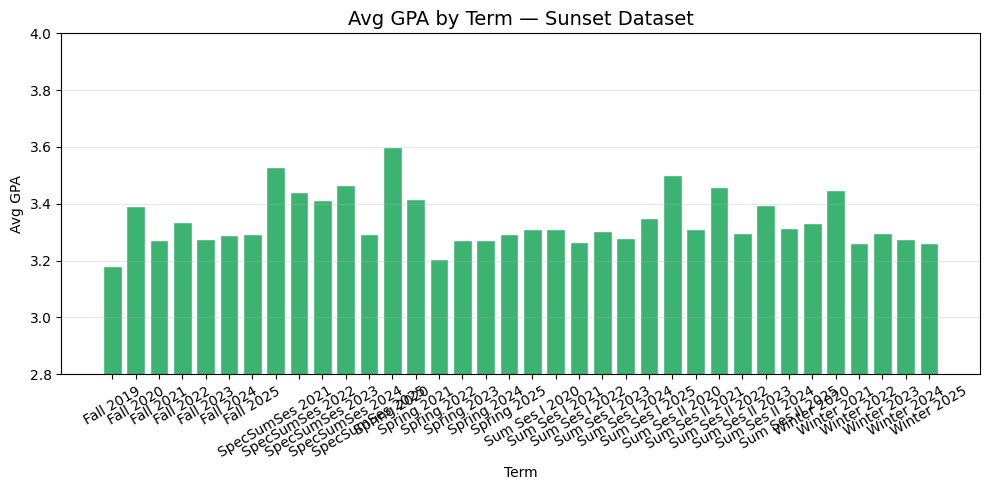

In [5]:
term_gpa = (
    df_clean.groupby('Term_clean')['GPA']
    .agg(['mean', 'count'])
    .sort_index()
)
print(term_gpa)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(term_gpa.index, term_gpa['mean'],
       color='mediumseagreen', edgecolor='white')
ax.set_title('Avg GPA by Term — Sunset Dataset', fontsize=14)
ax.set_xlabel('Term')
ax.set_ylabel('Avg GPA')
ax.set_ylim(2.8, 4.0)
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/sunset_term_gpa.png', dpi=150)
plt.show()

## 6. Grade Distribution Heatmap — Top Departments

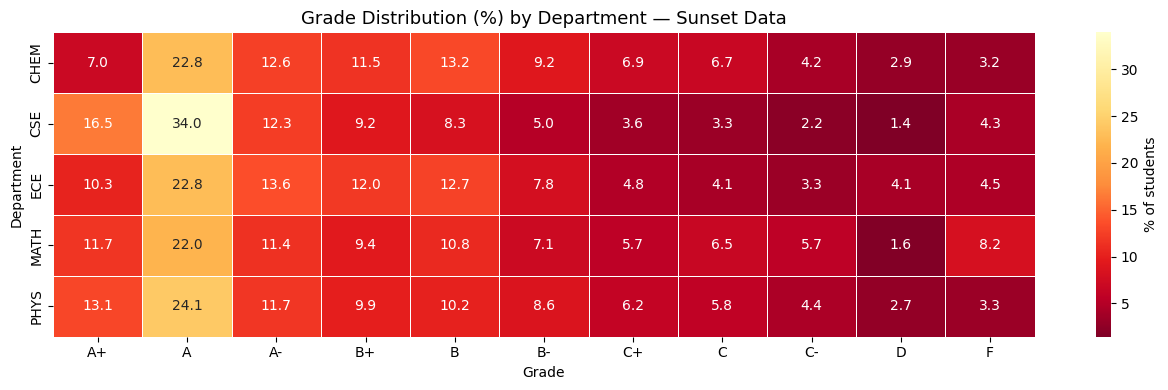

In [6]:
FOCUS = ['CSE', 'MATH', 'ECE', 'PHYS', 'CHEM']
FOCUS = [d for d in FOCUS if d in df_clean['Department'].unique()]

grade_order_plot = [g for g in ['A+','A','A-','B+','B','B-','C+','C','C-','D','F']
                    if g in df_clean.columns]

heatmap_data = (
    df_clean[df_clean['Department'].isin(FOCUS)]
    .groupby('Department')[grade_order_plot]
    .sum()
)
# Normalize to percentage
heatmap_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(heatmap_pct, annot=True, fmt='.1f', cmap='YlOrRd_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% of students'})
ax.set_title('Grade Distribution (%) by Department — Sunset Data', fontsize=13)
ax.set_xlabel('Grade')
ax.set_ylabel('Department')
plt.tight_layout()
plt.savefig('figures/sunset_grade_heatmap.png', dpi=150)
plt.show()

## 7. Sunset vs CAPES — GPA Comparison

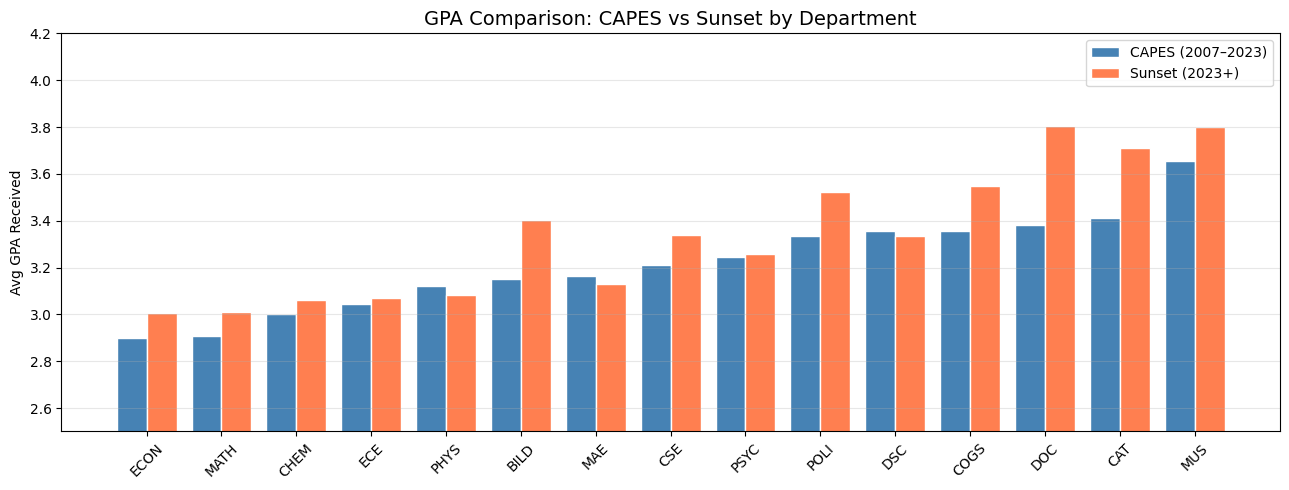

            CAPES (2007-2023)  Sunset (2023+)  Delta (Sunset - CAPES)
Department                                                           
ECON                    2.900           3.007                   0.106
MATH                    2.908           3.008                   0.100
CHEM                    3.000           3.060                   0.060
ECE                     3.046           3.069                   0.023
PHYS                    3.120           3.083                  -0.036
BILD                    3.150           3.402                   0.253
MAE                     3.162           3.131                  -0.031
CSE                     3.212           3.338                   0.126
PSYC                    3.246           3.260                   0.014
POLI                    3.335           3.522                   0.188
DSC                     3.355           3.334                  -0.021
COGS                    3.356           3.548                   0.192
DOC                 

In [7]:
# Load CAPES for comparison
capes = pd.read_csv(root_dir / 'data' / 'capes_data.csv')
capes['GPA_Received'] = capes['Average Grade Received'].str.extract(r'\(([\d.]+)\)').astype(float)
capes['Department']   = capes['Course'].str.extract(r'^([A-Z]+(?:\s[A-Z]+)?)\s+\d')
capes_clean = capes.dropna(subset=['GPA_Received', 'Department'])

common_depts = list(set(top15) & set(df_clean['Department'].unique()))

capes_dept = capes_clean[capes_clean['Department'].isin(common_depts)]\
    .groupby('Department')['GPA_Received'].mean().rename('CAPES (2007-2023)')
sunset_dept = df_clean[df_clean['Department'].isin(common_depts)]\
    .groupby('Department')['GPA'].mean().rename('Sunset (2023+)')

compare = pd.concat([capes_dept, sunset_dept], axis=1).dropna().sort_values('CAPES (2007-2023)')

x = range(len(compare))
width = 0.4
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar([i - width/2 for i in x], compare['CAPES (2007-2023)'],
       width=width, label='CAPES (2007–2023)', color='steelblue', edgecolor='white')
ax.bar([i + width/2 for i in x], compare['Sunset (2023+)'],
       width=width, label='Sunset (2023+)', color='coral', edgecolor='white')
ax.set_xticks(list(x))
ax.set_xticklabels(compare.index, rotation=45)
ax.set_ylim(2.5, 4.2)
ax.set_title('GPA Comparison: CAPES vs Sunset by Department', fontsize=14)
ax.set_ylabel('Avg GPA Received')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/sunset_vs_capes_dept.png', dpi=150)
plt.show()

compare['Delta (Sunset - CAPES)'] = compare['Sunset (2023+)'] - compare['CAPES (2007-2023)']
print(compare.round(3))